# RBG & Blitz Brackets — Rating Distribution Analysis
Fetch RBG and blitz brackets across 3 seasons to understand rating distributions,
sample sizes, and what `top_n` settings make sense before enabling RBG sync.

In [2]:
import json
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def fetch_all(brackets: list[str], season_ids: list[int], regions: list[str] = ["us", "eu"], batch_size: int = 30) -> dict:
    """Fetch multiple bracket/season/region combos in batches to avoid rate limits."""
    script = '''
require "json"

brackets   = %w[''' + ' '.join(brackets) + ''']
season_ids = [''' + ', '.join(str(s) for s in season_ids) + ''']
regions    = %w[''' + ' '.join(regions) + ''']
locales    = { "us" => "en_US", "eu" => "en_GB" }
batch_size = ''' + str(batch_size) + '''

jobs = []
brackets.each do |bracket|
  season_ids.each do |sid|
    regions.each do |region|
      jobs << [bracket, sid, region]
    end
  end
end

$stderr.puts "#{jobs.size} total calls, batch_size=#{batch_size}"

results = {}
mutex   = Mutex.new

jobs.each_slice(batch_size).with_index do |batch, bi|
  $stderr.puts "  batch #{bi + 1}/#{(jobs.size.to_f / batch_size).ceil}..."
  threads = batch.map do |bracket, sid, region|
    Thread.new do
      begin
        data = Blizzard::Api::GameData::PvpSeason::Leaderboard.fetch(
          pvp_season_id: sid, bracket: bracket, region: region, locale: locales[region]
        )
        entries = data.fetch("entries", [])
        mutex.synchronize { results["#{bracket}|#{sid}|#{region}"] = entries }
      rescue => e
        $stderr.puts "    #{region}/#{bracket}/s#{sid}: ERROR #{e.message[0..80]}"
        mutex.synchronize { results["#{bracket}|#{sid}|#{region}"] = [] }
      end
    end
  end
  threads.each(&:join)
end

$stderr.puts "done"
puts results.to_json
'''
    r = subprocess.run(
        ['bundle', 'exec', 'rails', 'runner', '-'],
        input=script, capture_output=True, text=True, cwd='..', timeout=300
    )
    if r.returncode != 0:
        print(f"Error: {r.stderr[:500]}")
        return {}
    print(r.stderr)
    return json.loads(r.stdout)

In [3]:
SEASONS = {41: "Midnight S1", 40: "TWW S3", 39: "TWW S2"}

# Discover all brackets from current season
print("Discovering brackets...")
disc_script = 'puts Blizzard::Api::GameData::PvpSeason::LeaderboardsIndex.fetch(pvp_season_id: PvpSeason.current.blizzard_id, region: "us").to_json'
r = subprocess.run(['bundle', 'exec', 'rails', 'runner', '-'], input=disc_script, capture_output=True, text=True, cwd='..')
all_brackets = [lb['name'] for lb in json.loads(r.stdout).get('leaderboards', [])]

# Keep only RBG + blitz brackets
RBG_BRACKETS = [b for b in all_brackets if b == 'rbg' or b.startswith('blitz-')]
print(f"Found {len(RBG_BRACKETS)} RBG/blitz brackets:")
for b in sorted(RBG_BRACKETS):
    print(f"  {b}")

Discovering brackets...
Found 42 RBG/blitz brackets:
  blitz-deathknight-blood
  blitz-deathknight-frost
  blitz-deathknight-unholy
  blitz-demonhunter-devourer
  blitz-demonhunter-havoc
  blitz-demonhunter-vengeance
  blitz-druid-balance
  blitz-druid-feral
  blitz-druid-guardian
  blitz-druid-restoration
  blitz-evoker-augmentation
  blitz-evoker-devastation
  blitz-evoker-preservation
  blitz-hunter-beastmastery
  blitz-hunter-marksmanship
  blitz-hunter-survival
  blitz-mage-arcane
  blitz-mage-fire
  blitz-mage-frost
  blitz-monk-brewmaster
  blitz-monk-mistweaver
  blitz-monk-windwalker
  blitz-overall
  blitz-paladin-holy
  blitz-paladin-protection
  blitz-paladin-retribution
  blitz-priest-discipline
  blitz-priest-holy
  blitz-priest-shadow
  blitz-rogue-assassination
  blitz-rogue-outlaw
  blitz-rogue-subtlety
  blitz-shaman-elemental
  blitz-shaman-enhancement
  blitz-shaman-restoration
  blitz-warlock-affliction
  blitz-warlock-demonology
  blitz-warlock-destruction
  blitz

In [4]:
# Fetch all RBG/blitz brackets across seasons
print(f"Fetching {len(RBG_BRACKETS)} brackets x {len(SEASONS)} seasons x 2 regions = {len(RBG_BRACKETS)*len(SEASONS)*2} calls...")
raw = fetch_all(RBG_BRACKETS, list(SEASONS.keys()))

all_rows = []
for key, entries in raw.items():
    bracket, sid_str, region = key.split("|")
    sid = int(sid_str)
    label = SEASONS[sid]
    for e in entries:
        all_rows.append({
            'bracket': bracket,
            'season': label,
            'season_id': sid,
            'region': region,
            'rank': e['rank'],
            'rating': e['rating'],
            'wins': e.get('season_match_statistics', {}).get('won', 0),
            'losses': e.get('season_match_statistics', {}).get('lost', 0),
        })

df = pd.DataFrame(all_rows)
print(f"Total rows: {len(df)}")

# Summary table
summary = (
    df.groupby(['bracket', 'season', 'region'])
    .agg(entries=('rating', 'size'), min_rating=('rating', 'min'), max_rating=('rating', 'max'), median_rating=('rating', 'median'))
    .reset_index()
)
summary['rating_range'] = summary['min_rating'].astype(str) + '–' + summary['max_rating'].astype(str)
summary = summary.sort_values(['bracket', 'season', 'region'])

pd.set_option('display.max_rows', 300)
summary

Fetching 42 brackets x 3 seasons x 2 regions = 252 calls...
252 total calls, batch_size=30
  batch 1/9...
  batch 2/9...
    us/blitz-demonhunter-devourer/s39: ERROR Blizzard API error: HTTP 404, body={"code":404,"type":"BLZWEBAPI00000404","detail
    eu/blitz-demonhunter-devourer/s39: ERROR Blizzard API error: HTTP 404, body={"code":404,"type":"BLZWEBAPI00000404","detail
  batch 3/9...
    eu/blitz-evoker-augmentation/s39: ERROR Blizzard API error: HTTP 504, body=<html>
<head><title>504 Gateway Time-out</tit
  batch 4/9...
  batch 5/9...
  batch 6/9...
  batch 7/9...
  batch 8/9...
  batch 9/9...
done

Total rows: 653674


,bracket,season,region,entries,min_rating,max_rating,median_rating,rating_range
0,blitz-deathknight-blood,Midnight S1,eu,174,287,2466,860.0,287–2466
1,blitz-deathknight-blood,Midnight S1,us,183,138,2671,859.0,138–2671
2,blitz-deathknight-blood,TWW S2,eu,543,138,3134,861.0,138–3134
3,blitz-deathknight-blood,TWW S2,us,632,287,2968,861.0,287–2968
4,blitz-deathknight-blood,TWW S3,eu,677,138,3612,863.0,138–3612
5,blitz-deathknight-blood,TWW S3,us,679,138,3164,862.0,138–3164
6,blitz-deathknight-frost,Midnight S1,eu,492,138,2767,856.5,138–2767
7,blitz-deathknight-frost,Midnight S1,us,483,138,2529,860.0,138–2529
8,blitz-deathknight-frost,TWW S2,eu,4210,138,3398,1154.0,138–3398
9,blitz-deathknight-frost,TWW S2,us,4630,133,3209,1149.0,133–3209


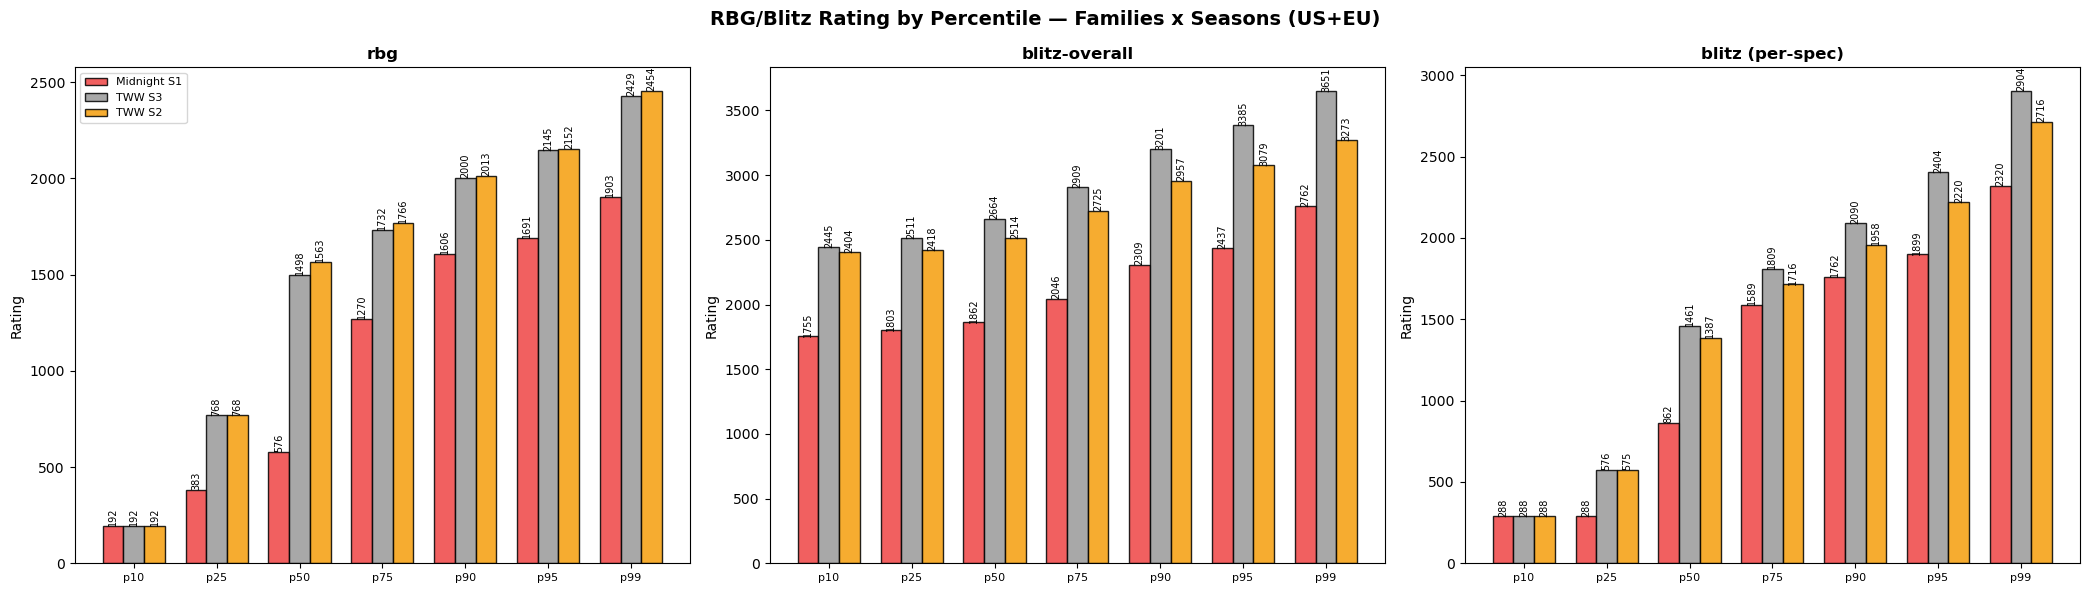

In [5]:
# Rating distribution by bracket family: RBG vs blitz-spec vs blitz-overall
percentiles = [10, 25, 50, 75, 90, 95, 99]
season_colors = {'Midnight S1': '#ef4444', 'TWW S3': '#999', 'TWW S2': '#f59e0b'}

def bracket_family(b):
    if b == 'rbg':
        return 'rbg'
    if b == 'blitz-overall':
        return 'blitz-overall'
    if b.startswith('blitz-'):
        return 'blitz (per-spec)'
    return 'other'

df['family'] = df['bracket'].apply(bracket_family)
families = [f for f in ['rbg', 'blitz-overall', 'blitz (per-spec)'] if f in df.family.values]

fig, axes = plt.subplots(1, max(len(families), 1), figsize=(7 * len(families), 6), sharey=False, squeeze=False)
axes = axes[0]

for idx, family in enumerate(families):
    ax = axes[idx]
    fdf = df[df.family == family]
    x = np.arange(len(percentiles))
    width = 0.25

    for i, (sid, label) in enumerate(SEASONS.items()):
        sdf = fdf[fdf.season == label]
        if sdf.empty:
            continue
        vals = [sdf.rating.quantile(p / 100) for p in percentiles]
        bars = ax.bar(x + i * width, vals, width, label=label,
                      color=season_colors.get(label, '#999'), edgecolor='black', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                    f'{v:.0f}', ha='center', fontsize=7, rotation=90)

    ax.set_xticks(x + width)
    ax.set_xticklabels([f'p{p}' for p in percentiles], fontsize=8)
    ax.set_title(family, fontsize=12, fontweight='bold')
    ax.set_ylabel('Rating')
    if idx == 0:
        ax.legend(fontsize=8)

fig.suptitle('RBG/Blitz Rating by Percentile — Families x Seasons (US+EU)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Sample size per blitz spec across seasons (US+EU combined)
blitz_df = df[df.bracket.str.startswith('blitz-') & (df.bracket != 'blitz-overall')].copy()
blitz_df['spec'] = blitz_df['bracket'].str.replace('blitz-', '', regex=False)

if not blitz_df.empty:
    sample = (
        blitz_df.groupby(['spec', 'season'])
        .agg(total=('rating', 'size'), median_rating=('rating', 'median'))
        .reset_index()
        .pivot(index='spec', columns='season', values=['total', 'median_rating'])
    )
    sample.columns = [f'{stat}_{season}' for stat, season in sample.columns]
    first_season = list(SEASONS.values())[0]
    if f'total_{first_season}' in sample.columns:
        sample = sample.sort_values(f'total_{first_season}', ascending=False)

    def highlight_thin(val):
        if isinstance(val, (int, float)) and val < 200:
            return 'color: red; font-weight: bold'
        return ''

    styled = sample.style.map(highlight_thin, subset=[c for c in sample.columns if c.startswith('total_')])
    styled.format('{:.0f}')
else:
    print("No blitz per-spec brackets found (may not exist for these seasons)")

In [7]:
# What does top_n capture? Test different top_n values for RBG/blitz
top_n_options = [250, 500, 750, 1000]

rows = []
for bracket in RBG_BRACKETS:
    for sid, label in SEASONS.items():
        bdf = df[(df.bracket == bracket) & (df.season_id == sid)]
        if bdf.empty:
            continue
        total = len(bdf)
        for top_n in top_n_options:
            captured = min(top_n, total)
            floor_rating = bdf.nlargest(captured, 'rating').rating.min() if captured > 0 else None
            rows.append({
                'bracket': bracket,
                'season': label,
                'leaderboard_size': total,
                'top_n': top_n,
                'captured': captured,
                'floor_rating': floor_rating,
                '% of leaderboard': round(captured / total * 100, 1) if total > 0 else 0,
            })

capture_df = pd.DataFrame(rows)

# Show pivoted: one row per bracket/season, columns for each top_n
pivot = capture_df.pivot_table(
    index=['bracket', 'season', 'leaderboard_size'],
    columns='top_n',
    values=['captured', 'floor_rating'],
    aggfunc='first'
)
pivot.columns = [f'{stat}_top{n}' for stat, n in pivot.columns]
pivot = pivot.reset_index().sort_values(['bracket', 'season'])
pivot

,bracket,season,leaderboard_size,captured_top250,captured_top500,captured_top750,captured_top1000,floor_rating_top250,floor_rating_top500,floor_rating_top750,floor_rating_top1000
0,blitz-deathknight-blood,Midnight S1,357,250,357,357,357,288,138,138,138
1,blitz-deathknight-blood,TWW S2,1175,250,500,750,1000,1643,1137,575,288
2,blitz-deathknight-blood,TWW S3,1356,250,500,750,1000,1755,1420,844,288
3,blitz-deathknight-frost,Midnight S1,975,250,500,750,975,1575,856,288,138
4,blitz-deathknight-frost,TWW S2,8840,250,500,750,1000,2415,2122,1968,1868
5,blitz-deathknight-frost,TWW S3,6751,250,500,750,1000,2308,2045,1891,1824
6,blitz-deathknight-unholy,Midnight S1,4736,250,500,750,1000,1884,1803,1682,1632
7,blitz-deathknight-unholy,TWW S2,6183,250,500,750,1000,2145,1941,1824,1794
8,blitz-deathknight-unholy,TWW S3,11624,250,500,750,1000,2556,2407,2202,2096
9,blitz-demonhunter-devourer,Midnight S1,2007,250,500,750,1000,1684,1577,1366,862


Fetching ['2v2', '3v3'] for context comparison...
12 total calls, batch_size=30
  batch 1/1...
done



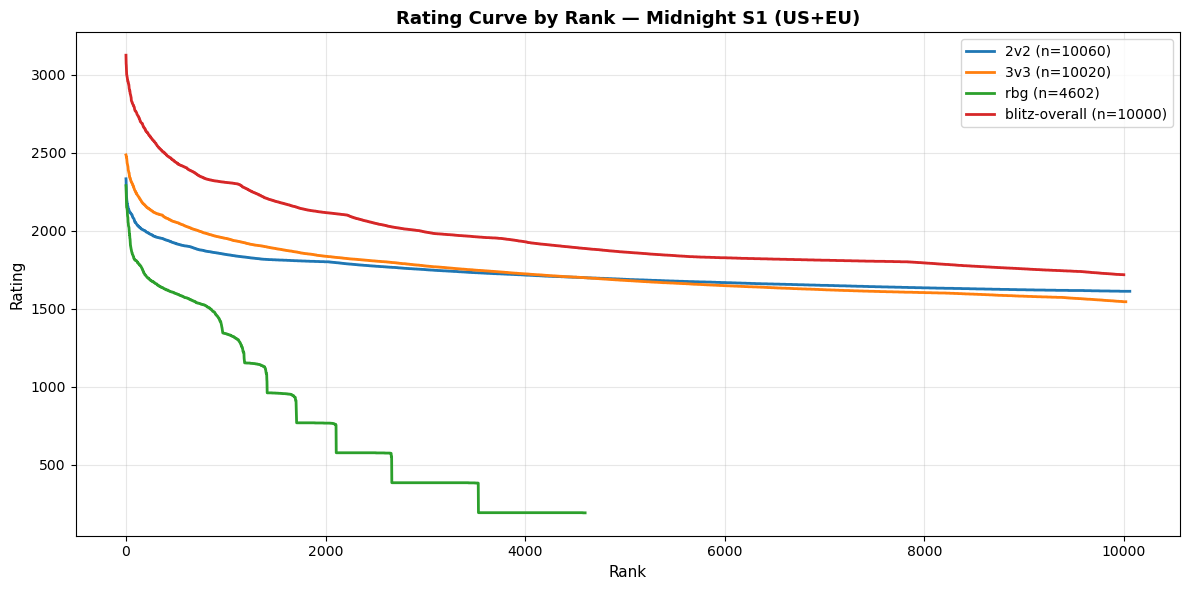

In [8]:
# Compare RBG vs arena vs shuffle distributions side by side
# Fetch a small sample of arena/shuffle for context
CONTEXT_BRACKETS = ['2v2', '3v3', 'rbg']
# Only fetch context brackets if rbg is already in df
context_brackets_to_fetch = [b for b in ['2v2', '3v3'] if b not in df.bracket.values]

if context_brackets_to_fetch:
    print(f"Fetching {context_brackets_to_fetch} for context comparison...")
    ctx_raw = fetch_all(context_brackets_to_fetch, list(SEASONS.keys()))
    for key, entries in ctx_raw.items():
        bracket, sid_str, region = key.split("|")
        sid = int(sid_str)
        label = SEASONS[sid]
        for e in entries:
            all_rows.append({
                'bracket': bracket,
                'season': label,
                'season_id': sid,
                'region': region,
                'rank': e['rank'],
                'rating': e['rating'],
                'wins': e.get('season_match_statistics', {}).get('won', 0),
                'losses': e.get('season_match_statistics', {}).get('lost', 0),
            })
    df_full = pd.DataFrame(all_rows)
else:
    print("Fetching 2v2, 3v3 for context comparison...")
    ctx_raw = fetch_all(['2v2', '3v3'], list(SEASONS.keys()))
    ctx_rows = []
    for key, entries in ctx_raw.items():
        bracket, sid_str, region = key.split("|")
        sid = int(sid_str)
        label = SEASONS[sid]
        for e in entries:
            ctx_rows.append({
                'bracket': bracket,
                'season': label,
                'season_id': sid,
                'region': region,
                'rank': e['rank'],
                'rating': e['rating'],
                'wins': e.get('season_match_statistics', {}).get('won', 0),
                'losses': e.get('season_match_statistics', {}).get('lost', 0),
            })
    df_full = pd.concat([df, pd.DataFrame(ctx_rows)], ignore_index=True)

# Plot: RBG vs 2v2 vs 3v3 rating distributions for latest season
latest_season = list(SEASONS.values())[0]
compare_brackets = ['2v2', '3v3', 'rbg']
# Add blitz-overall if it exists
if 'blitz-overall' in df_full.bracket.values:
    compare_brackets.append('blitz-overall')

fig, ax = plt.subplots(figsize=(12, 6))
for bracket in compare_brackets:
    bdf = df_full[(df_full.bracket == bracket) & (df_full.season == latest_season)]
    if bdf.empty:
        continue
    ratings = bdf.rating.sort_values(ascending=False).reset_index(drop=True)
    ax.plot(ratings.index, ratings.values, label=f"{bracket} (n={len(ratings)})", linewidth=2)

ax.set_xlabel('Rank', fontsize=11)
ax.set_ylabel('Rating', fontsize=11)
ax.set_title(f'Rating Curve by Rank — {latest_season} (US+EU)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

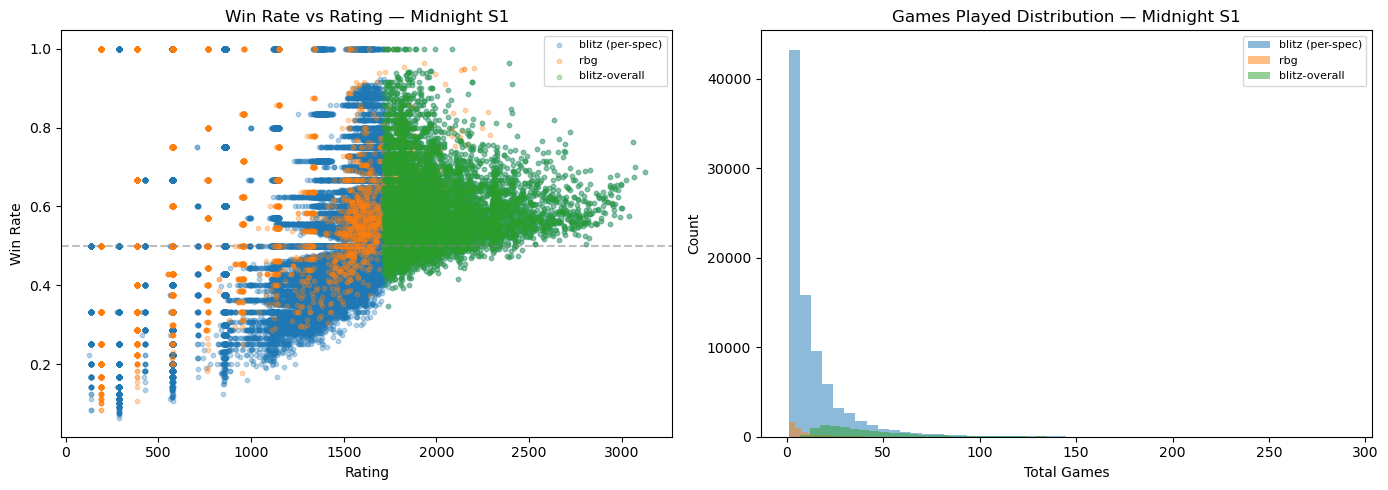

In [9]:
# Win rate distribution for RBG brackets
rbg_df = df[df.family.isin(['rbg', 'blitz-overall', 'blitz (per-spec)'])].copy()
rbg_df['total_games'] = rbg_df['wins'] + rbg_df['losses']
rbg_df['winrate'] = rbg_df['wins'] / rbg_df['total_games'].replace(0, np.nan)

latest = rbg_df[rbg_df.season == latest_season]

if not latest.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Win rate vs rating scatter
    ax = axes[0]
    for family in latest.family.unique():
        fdf = latest[latest.family == family]
        ax.scatter(fdf.rating, fdf.winrate, alpha=0.3, s=10, label=family)
    ax.set_xlabel('Rating')
    ax.set_ylabel('Win Rate')
    ax.set_title(f'Win Rate vs Rating — {latest_season}')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

    # Games played distribution
    ax = axes[1]
    for family in latest.family.unique():
        fdf = latest[latest.family == family]
        ax.hist(fdf.total_games, bins=50, alpha=0.5, label=family)
    ax.set_xlabel('Total Games')
    ax.set_ylabel('Count')
    ax.set_title(f'Games Played Distribution — {latest_season}')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No RBG data for latest season")

## Conclusions

### Key Findings

1. **Classic RBG is dead.** Only 4,602 entries with a staircase rating curve — most players below 800 rating. Not worth syncing.

2. **Blitz is the real bracket.** 10,000 entries (on par with 2v2/3v3), smooth rating curve from 3100 down to 1700. Highest peak ratings of any bracket. Blitz replaced classic RBG as the main rated BG mode — it's solo-queue (like shuffle but for BGs).

3. **Blitz per-spec brackets exist** — 40 spec-specific leaderboards (same structure as shuffle). This gives us spec-level gear/talent meta for battlegrounds.

4. **Win rate vs rating** is clean for blitz (higher rating → higher winrate funnel). RBG is scattered noise. Most players have <25 games played (early season).

### Implementation

**Sync blitz per-spec only. Skip classic RBG and blitz-overall.**

| Bracket | Action | Reason |
|---------|--------|--------|
| `rbg` | Skip (`SKIP_BRACKETS`) | Dead bracket, noisy data |
| `blitz-overall` | Skip (`SKIP_BRACKETS`) | Redundant — covered by per-spec brackets |
| `blitz-{class}-{spec}` | **Sync** | Per-spec meta data, like shuffle |

**Config:** Reuse `rbg_like` family with `top_n: 500`, rename to `blitz_like`. Route `blitz-*` per-spec brackets to `:pvp_sync_blitz` queue.